# Lezione 3: Pipeline per Apprendimento Automatico (supervisionato)

In questa lezione ci occupiamo di costruire la corretta **pipeline** per l'addestramento di modelli di apprendimento automatico supervisionato. L'approccio adottato è di tipo **pratico**: trattiamo i modelli come "black box" (affididandoci alle funzioni della libreria **scikit-learn**) e ci concentriamo sull'implementazione del codice relativo alla procedura che garantisce un processo di apprendimento rigoroso e scientificamente valido.

---

Una pipeline ben strutturata si articola nei seguenti passaggi fondamentali:

1. **Exploratory Data Analysis (EDA)**: insieme delle tecniche di visualizzazione utili a guidare il programmatore nelle scelte di modellazione (determinare il *bias induttivo* appropriato per il problema). La EDA si articola in:

    - **Analisi univariata**  
    Studio di ciascuna variabile singolarmente per comprenderne la distribuzione, le statistiche descrittive principali (media, mediana, deviazione standard), individuare valori anomali o mancanti e decidere come gestirli.

    - **Analisi bivariata**  
    Analisi delle relazioni tra coppie di variabili (tipicamente singola feature - target) al fine di identificare pattern, correlazioni o dipendenze.

    - **Analisi multivariata**  
    Studio congiunto di tre o più variabili per comprendere la struttura globale del dataset e individuare eventuali interazioni non evidenti nelle analisi precedenti.


2. **Model Selection and Evaluation**: procedura di addestramento che incorpora la selezione degli iperparametri ottimali e valutazione della *stabilità* e *capacità di generalizzazione* del modello (**Nested K-Fold Cross-Validation**).

Per **iperparametri** si intendono quei parametri del processo di apprendimento che **Non vengono appresi** automaticamente dall'algoritmo durante il training (devono essere **specificati a priori** dal data scientist).

## Il Dataset Diabetes

Il problema di apprendimento che affrontiamo è esemplificato dal dataset **diabetes**, che contiene:
- **Variabili (features)**: misurazioni mediche relative a pazienti
- **Target**: variabile binaria che indica la presenza (1) o assenza (0) di diabete

L'obiettivo è allenare un modello capace di predire se un paziente è diabetico sulla base delle sue caratteristiche cliniche.

In [15]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from utils import plot_boxplots, plot_histograms, plot_pairplot_with_correlation

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./Data/diabetes.csv')

---

## Exploratory Data Analysis (univariata)

Outcome. Per scoprire il contenuto di questo dataset e iniziare a familiarizzare con la realtà da esso rappresentata, operiamo 2 semplici operazioni sul dataframe `df` (in celle separate):

* `df.head(3)` : visualizzo i primi 3 record del dataframe,
* `df.describe()` (modificato) : visualizzo le statistiche indicative delle distribuzioni delle singole features: 

    - (1) il numero di features ($d$), 

    - (2) il tipo di ogni feature, 

    - (3) la cardinalità $m$ del dataframe (numero di record), 

    - (4) il numero di dati mancanti (Nan) per ogni feature.

    - (5) la *media* di ogni feature, 

    - (6) la *deviazione standard* di ogni feature (in media, quanto dista ciascun valore della feature dal suo valor medio), 

    - (7) il *range* di valori di ogni feature (intervallo valore minimo - valore massimo), 

    - (8) i princiapli *percentili* (per esempio: il $25$-esimo percentile rappresenta il valore al di sotto del quale cade il 25% dei valori della feature presenti nel dataframe).


In [16]:
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [17]:
desc = df.describe(include='all').T
desc['dtype'] = df.dtypes
desc['Nan'] = df.isna().sum()
desc

,count,mean,std,min,25%,50%,75%,max,dtype,Nan
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00,int64,0
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00,int64,0
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00,int64,0
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00,int64,0
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00,int64,0
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10,float64,0
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42,float64,0
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00,int64,0
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00,int64,0


A seguito di questa analisi preliminare, è possibile trarre le seguenti considerazioni:

- Il dataset è composto da $d=8$ variabili, di cui 6 a valori interi (`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `Age`) e 2 a valori continui (`DiabetesPedigreeFunction` e `BMI`).

- Il dataset comprende una variabile target `Outcome`, questa è binaria e prende valori in $\{0,1\}$.

- Il dataset è composto da $m=768$ esempi (coppie features-target).

- Sebbene non risultino valori mancanti espliciti, alcune feature `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` presentano valori pari a zero, che risultano non plausibili dal punto di vista clinico (ad esempio, una pressione sanguigna nulla). Tali valori vengono pertanto interpretati come valori mancanti (NaN) e richiederanno un opportuno trattamento in fase di preprocessing.

- Il valore medio della variabile target `Outcome` indica una prevalenza della classe 0 (≈ 65.1%) rispetto alla classe 1 (≈ 34.9%), suggerendo la presenza di un moderato sbilanciamento del dataset, seppur non eccessivo. 

In [18]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[[
	'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)

desc = df.describe(include='all').T
desc['dtype'] = df.dtypes
desc['Nan'] = df.isna().sum()
desc

,count,mean,std,min,25%,50%,75%,max,dtype,Nan
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00,int64,0
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00,float64,5
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00,float64,35
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00,float64,227
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00,float64,374
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10,float64,11
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42,float64,0
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00,int64,0
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00,int64,0


L’analisi dei valori mancanti evidenzia che alcune feature presentano una quantità significativa di dati non osservati:
- La feature `Insulin` contiene 374 valori mancanti, pari a circa **la metà** della cardinalità totale del dataset.

- la feature `SkinThickness` presenta 227 valori mancanti, ovvero **più di un terzo** del numero totale di esempi.

Data l’elevata percentuale di valori mancanti, queste due feature vengono **rimosse dall’analisi** e non verranno incluse nel successivo processo di apprendimento, poiché un’eventuale imputazione (sostituzione del nvalore Nan con media, mediana o altre tecniche basate sulla distribuzione empirica delle feature) risulterebbe poco affidabile.

Per quanto riguarda `BloodPressure`, `Glucose` e `BMI`, il numero di valori mancanti è invece più contenuto. In linea di principio, sarebbe possibile imputare tali valori. Tuttavia, questa operazione **non può essere effettuata in questa fase**. La motivazione è la seguente:

Il processo di Model selection and evaluation prevede che il dataset venga suddiviso più volte in training set e test/validation set. Operazioni di preprocessing come:
- imputazione dei valori mancanti,
- standardizzazione delle feature,
- bilanciamento delle classi,

devono essere eseguite esclusivamente sulla base delle statistiche del training set e successivamente applicate ai corrispondenti test/validation set. (Ad esempio, nel caso della standardizzazione, media e deviazione standard devono essere calcolate solo sul training set, e poi utilizzate per trasformare anche i dati di test/validation.)

L’utilizzo di informazioni provenienti dai dati di test/validation durante il preprocessing dei dati di training porterebbe infatti al fenomeno noto come data leakage, compromettendo la validità della valutazione del modello.

In questa fase preliminare, le uniche operazioni consentite sono la rimozione di colonne o di righe del dataframe. Si decide pertanto di:
- eliminare le colonne `Insulin` e `SkinThickness`;
- rimuovere le righe che presentano valori mancanti per la feature `Glucose`.

In [19]:
# OPZIONE 1: Rimozione colonne con valori mancanti
df = df.drop(columns=['Insulin', 'SkinThickness'])

# OPZIONE 2: Rimozione righe con valori mancanti
df = df.dropna(subset=['Glucose'])

desc = df.describe(include='all').T
desc['dtype'] = df.dtypes
desc['Nan'] = df.isna().sum()
desc

,count,mean,std,min,25%,50%,75%,max,dtype,Nan
Pregnancies,763.0,3.851900,3.374729,0.000,1.0000,3.000,6.0000,17.00,int64,0
Glucose,763.0,121.686763,30.535641,44.000,99.0000,117.000,141.0000,199.00,float64,0
BloodPressure,728.0,72.438187,12.386109,24.000,64.0000,72.000,80.0000,122.00,float64,35
BMI,752.0,32.454654,6.928926,18.200,27.5000,32.300,36.6000,67.10,float64,11
DiabetesPedigreeFunction,763.0,0.472477,0.331963,0.078,0.2435,0.374,0.6265,2.42,float64,0
Age,763.0,33.271298,11.772161,21.000,24.0000,29.000,41.0000,81.00,int64,0
Outcome,763.0,0.348624,0.476847,0.000,0.0000,0.000,1.0000,1.00,int64,0


Per le feature `BloodPressure` e `BMI` è necessario stabilire una strategia di imputazione dei valori mancanti. A tal fine, analizziamo preliminarmente le distribuzioni empiriche di ciascuna feature sulla base delle osservazioni disponibili nel dataset.

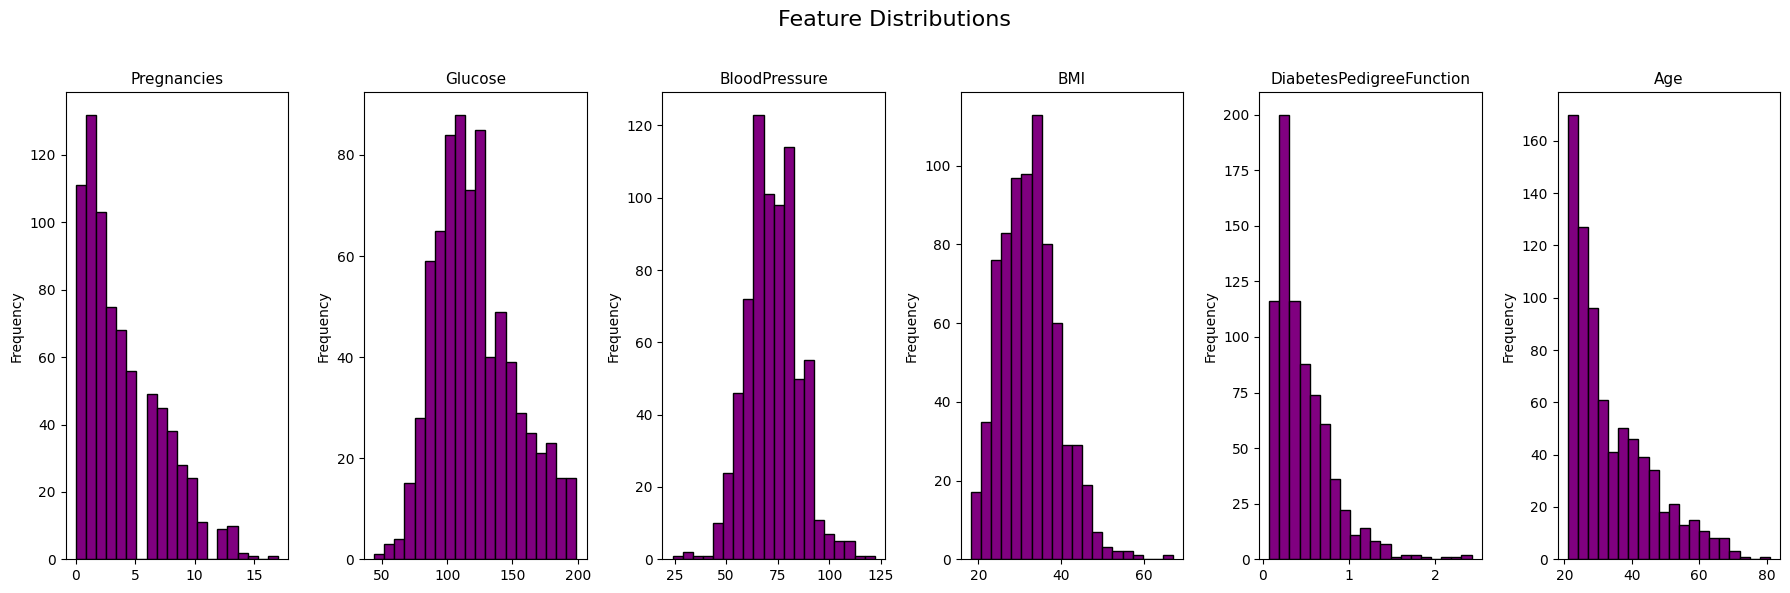

In [20]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']
plot_histograms(df, features)

Dall’analisi delle distribuzioni emerge che:

- `BloodPressure` presenta una distribuzione sufficientemente simmetrica; di conseguenza, risulta appropriato imputare i valori mancanti utilizzando il valore medio della feature.

- `BMI`, invece, mostra una distribuzione asimmetrica e la presenza di potenziali valori estremi; per questo motivo, si preferisce imputare i valori mancanti utilizzando la mediana, più robusta rispetto agli outlier.

In entrambi i casi, l’imputazione verrà effettuata calcolando media e mediana esclusivamente sul training set di riferimento e applicando tali statistiche ai corrispondenti set di validation e test, al fine di evitare fenomeni di data leakage.

---

## Exploratory Data Analysis (bivariata)

Dopo aver completato l’analisi preliminare delle singole feature, procediamo con l’analisi bivariata, il cui obiettivo principale è investigare la relazione tra ciascuna feature e la variabile target `Outcome`. In particolare, questa fase dell’analisi mira a rispondere alla seguente domanda: quali feature, tra quelle considerate, consentono una migliore discriminazione tra la classe `Outcome` = 0 (assenza di diabete) e la classe `Outcome` = 1 (presenza di diabete)?

L’analisi bivariata permette quindi di valutare il potere discriminante di ciascuna variabile rispetto al target, fornendo indicazioni utili per le successive fasi di modellazione e selezione delle feature.

Procediamo producendo i boxplot delle principali variabili indipendenti rispetto alla variabile target `Outcome`, consentendo di confrontare la distribuzione empirica di ciascuna feature tra le due classi (`Outcome = 0` e `Outcome = 1`).

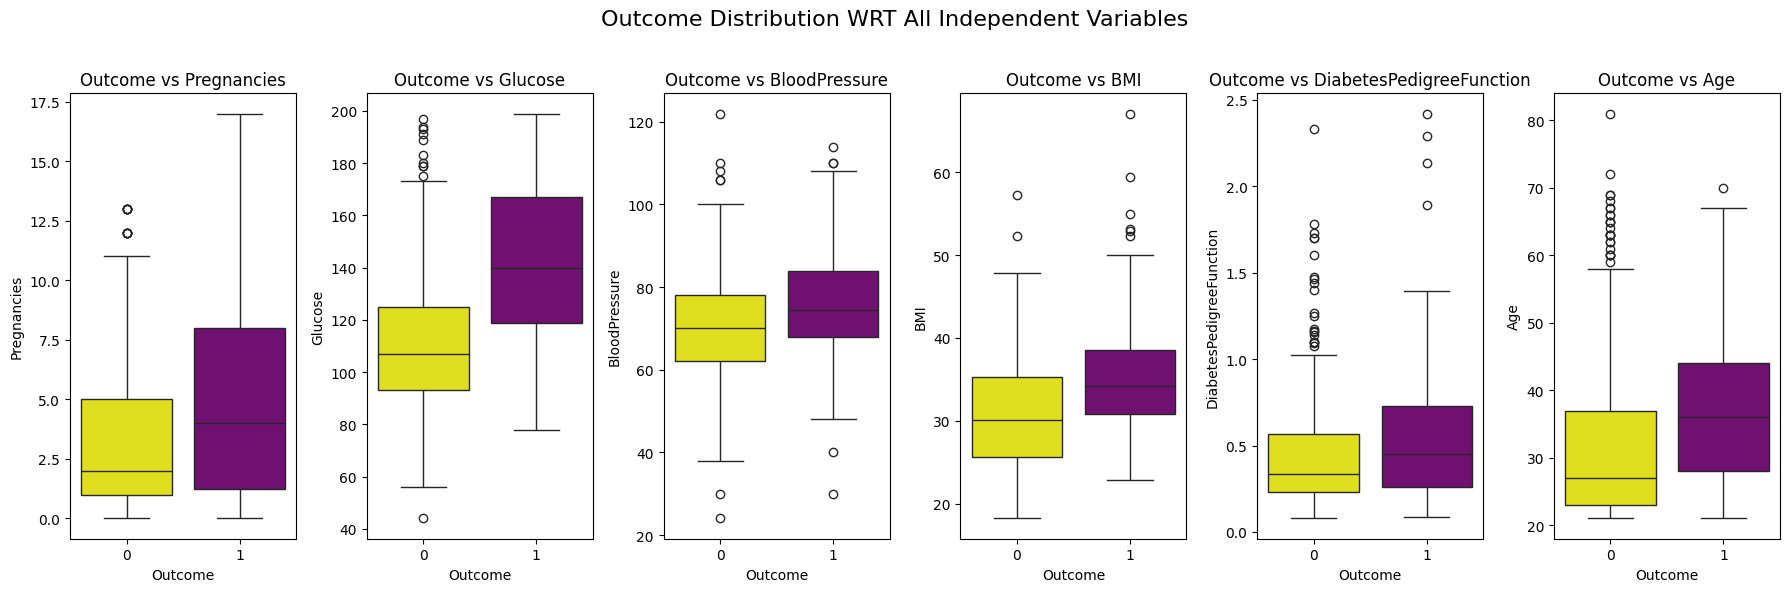

In [21]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']
plot_boxplots(df, features, target='Outcome')

Dall’analisi emergono le seguenti osservazioni:

- **Glucose**  
  È la feature che mostra la **separazione più marcata** tra le due classi. La mediana e l’intero intervallo interquartile per `Outcome = 1` risultano significativamente più elevati rispetto a `Outcome = 0`. Questo indica un **forte potere discriminante** della glicemia rispetto alla presenza di diabete.

- **BMI**  
  Anche il BMI presenta una differenza evidente tra le due classi: i soggetti con `Outcome = 1` tendono ad avere valori medi e mediani più alti. Sebbene vi sia una parziale sovrapposizione tra le distribuzioni, la feature risulta **informativa** ai fini della classificazione.

- **Age**  
  La distribuzione dell’età mostra uno spostamento verso valori più elevati per `Outcome = 1`. Questo suggerisce che l’età contribuisce alla discriminazione tra le classi, seppur in misura **meno netta** rispetto a Glucose e BMI.

- **Pregnancies**  
  Si osserva una maggiore variabilità e valori medi più elevati per `Outcome = 1`. La feature appare **moderatamente discriminante**, in particolare per valori più alti del numero di gravidanze.

- **DiabetesPedigreeFunction**  
  Le due distribuzioni risultano parzialmente sovrapposte, ma con una mediana leggermente più alta per `Outcome = 1`. La feature fornisce **informazione aggiuntiva**, sebbene il suo potere discriminante sia limitato se considerata isolatamente.

- **BloodPressure**  
  È la feature che mostra la **minore differenza** tra le due classi: le distribuzioni sono fortemente sovrapposte e le mediane risultano simili. Questo suggerisce un **basso potere discriminante** rispetto al target.

Nel complesso, l’analisi bivariata evidenzia che **Glucose**, seguita da **BMI** e **Age**, è la variabile più informativa per discriminare tra soggetti diabetici e non diabetici. Le altre feature contribuiscono in misura minore e risultano potenzialmente utili soprattutto in combinazione, all’interno di un modello multivariato.

---


## Exploratory Data Analysis (multivariata)

L’ultimo passaggio dell’analisi esplorativa dei dati è l’**analisi multivariata**, il cui obiettivo principale è individuare eventuali **interdipendenze** tra le feature sopravvissute ai precedenti passaggi di preprocessing.

L’identificazione di tali interdipendenze è particolarmente rilevante nel contesto dei **modelli lineari**. In presenza di feature fortemente collineari, infatti, le stime dei coefficienti possono diventare instabili e ad alta varianza. In questi casi, l’introduzione di tecniche di **regolarizzazione** (ad esempio L2/Ridge o L1/Lasso) risulta utile per stabilizzare il modello e migliorare la capacità di generalizzazione. Al contrario, in assenza di collinearità significative, un modello non regolarizzato può risultare sufficiente e più facilmente interpretabile.

Un’ulteriore utilità dell’analisi multivariata consiste nell’individuazione di **feature ridondanti**, ovvero variabili che forniscono informazioni simili o sovrapposte rispetto al task di classificazione. L’eliminazione di tali feature può semplificare il modello senza compromettere le prestazioni predittive.

Per valutare le interdipendenze tra le variabili, analizziamo:
- un **pairplot**, che permette di osservare visivamente le relazioni tra le feature;
- l'**indice di correlazione di Pearson**, che fornisce una misura quantitativa della forza e della direzione delle relazioni lineari tra coppie di variabili.


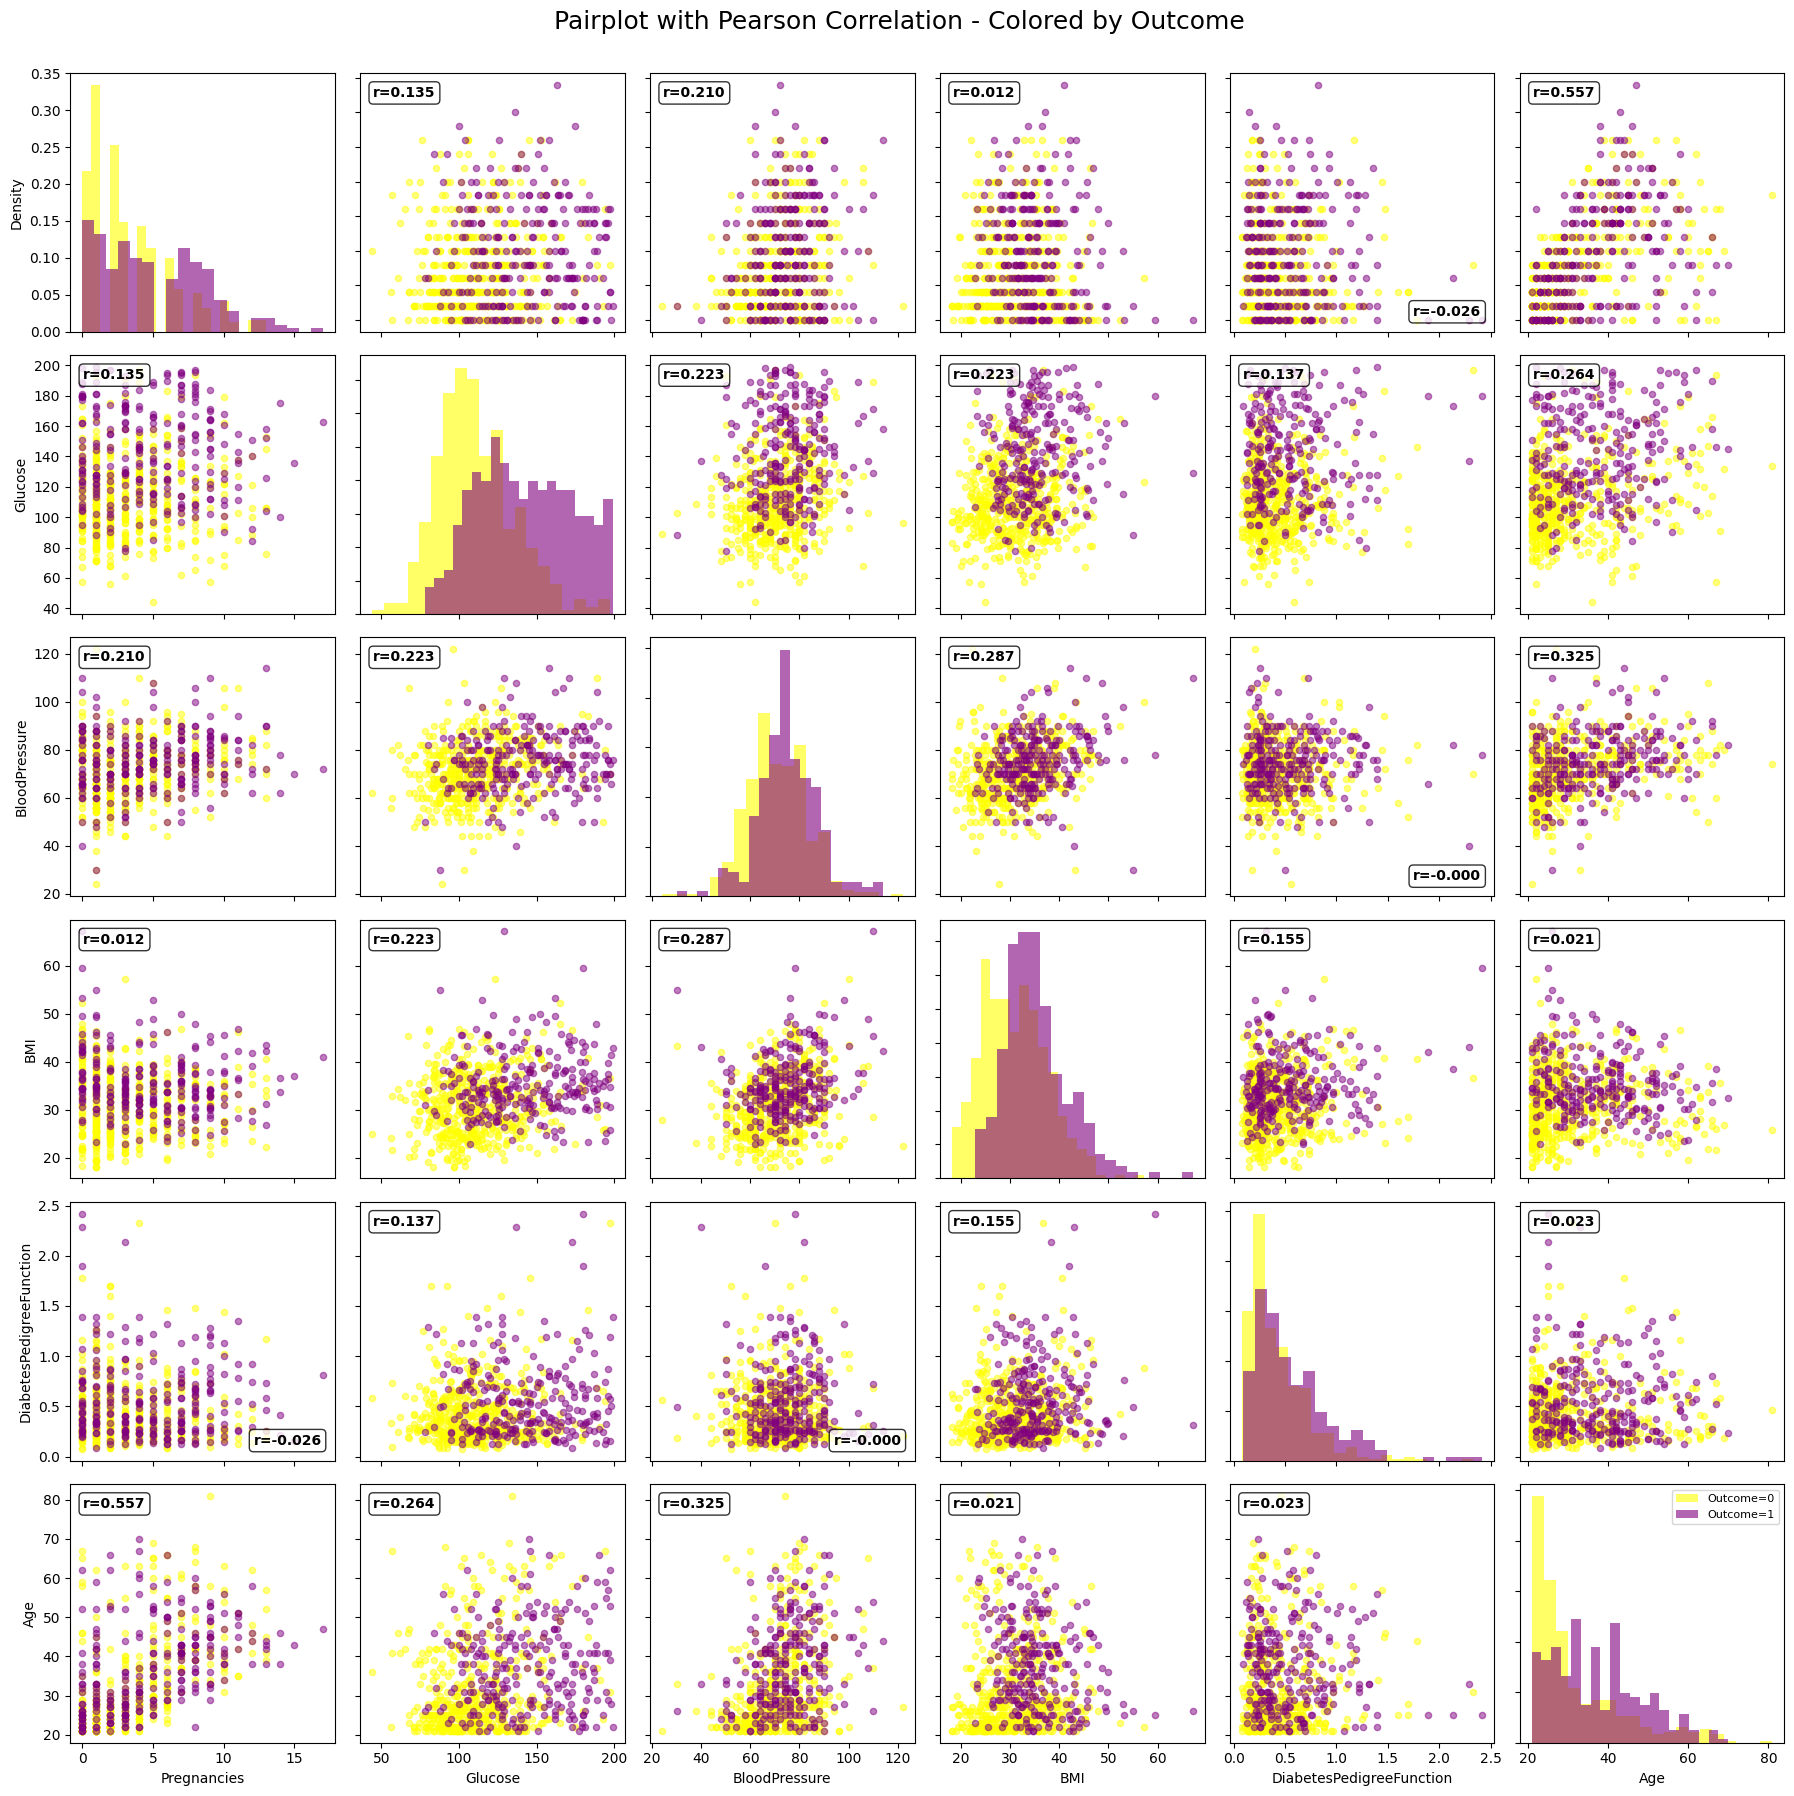

In [22]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']
plot_pairplot_with_correlation(df, features, target='Outcome')

Dall’osservazione del pairplot emergono le seguenti considerazioni:

- **Assenza di collinearità forte**  
  I coefficienti di correlazione tra le feature risultano generalmente **bassi o moderati**. I valori massimi osservati (ad esempio tra `Pregnancies` e `Age`, con $(r \approx 0.56)$) indicano una correlazione positiva significativa ma **non tale da configurare una collinearità critica**. Non sono presenti coppie di variabili con correlazione prossima a 1 in valore assoluto.

Dal punto di vista della modellazione, questa analisi suggerisce che non vi siano forti vincoli strutturali che impongano l’uso della regolarizzazione per garantire stabilità durante il processo di apprendimento.

---


## Model Selection and Evaluation

La nested K-fold CV è una procedura a due livelli: un ciclo $\textit{interno}$ per la selezione degli iperparametri e un ciclo $\textit{esterno}$ per la valutazione del modello. Lo schema procedurale della nested K-fold CV è riportato qui di seguito: 

- Divido il dataset $S$ in $K$ fold $(S_1,…, S_K)$.

- Per ogni $i=1,\dots,K$: 
    - TRAINING SET (esterno): $S’=(S_1,…,S_K) \setminus S_i$,  
    - TEST SET (esterno): $S_i$.

    - Per ogni tupla di iperparametri $\rho \in \Rho$: 
        - Divido $S’$ in $K’$ fold $(S’_1,…, S’_K’)$.
        - Per ogni $j = 1,.., K’$:

            - TRAINING SET (interno): $(S’_1,…,S’_{K’})\setminus S’_j$,
            - VALIDATION SET (interno): $S’_j$.
            - Standardizzo training set interno: applico le medie e le std del training set interno anche al validation set $\rightarrow$ no data leakage.
            - Training $A_{\rho}$ sul training set interno.
            - Testing $A_{\rho}$ su validation set $S’_j$ $\rightarrow$ salvo l’errore $E’_{\rho}(j)$.

        - Calcolo l'errore medio sui $K’$ disponibili $\rightarrow$ salvo l'errore medio $\bar{E’}_{\rho}$.

    - Prendo la tupla di iperparametri $\hat{\rho}$ che produce errore medio $\bar{E’}_{\hat{\rho}}$ minore.
    - Standardizzo training set esterno: applico le medie e std del training set esterno anche al test set $\rightarrow$ no data leakage.
    - Training $A_{\hat{\rho}}$ sul training set esterno $S’$ $\rightarrow$  salvo il modello $A_{\hat{\rho}}$.
    - Testing $A_{\hat{\rho}}$ sul test set $S_i$ $\rightarrow$ salvo l’errore $E_{\hat{\rho}}(i)$.

- Calcolo errore medio sui $K$ disponibili ->  $\bar{E}_{\hat{\rho}}$.



Nel seguente codice utilizziamo la libreria **scikit-learn** per costruire l’intera pipeline di apprendimento della **Logistic Regression** applicata al dataset `diabetes.csv`. I principali metodi di apprendimento regolarizzati cercano di risolvere problemi della forma:
$$
\underset{\mathbf{w}}{\text{min}} \:\ell_{S_m}(\mathbf{w}) + \lambda \Omega(\mathbf{w})
$$

Per implementare la nested K-fold CV dobbiamo quindi definire:
1. **Preprocessing dei dati**  
   - I valori mancanti (`NaN`) per `BloodPressure` vengono sostituiti con la **media** calcolata sul training set corrispondente.  
   - I valori mancanti per `BMI` vengono sostituiti con la **mediana** calcolata sul training set.  
   - Tutte le feature vengono **standardizzate** (media 0 e deviazione standard 1) usando esclusivamente i parametri calcolati sul training set, applicando la trasformazione a training, validation e test set.
2. **Definizione degli iperparametri del modello**  
   Ogni tupla di iperparametri contiene tre elementi:  
   * **$\lambda$**: parametro di regolarizzazione (in scikit-learn espresso come `clf__C = 1/λ`).  
   * **Tipo di regolarizzazione**:  
      - `l1` (Lasso) → penalizza la somma dei valori assoluti dei pesi:  $\lambda \sum_{j=1}^{d}|w_j|$
      - `l2` (Ridge) → penalizza la somma dei quadrati dei pesi:  $\lambda \sum_{j=1}^{d} w_j^2$ 
   * **Algoritmo di ottimizzazione**: ad esempio `SAG`, una variante di **Stochastic Gradient Descent** che mantiene memoria dei gradienti passati.
3. **Nested K-fold cross-validation**  
   - Vengono definiti i valori di \(K\) e \(K'\) per le fasi interna ed esterna della CV annidata.

4. **Bilanciamento delle classi**  
   - Nei training set specifici, il bilanciamento delle classi viene gestito impostando, nel classificatore `LogisticRegression`:  
     ```python
     class_weight='balanced'
     ```  

5. **Metrica di valutazione**  
   - Essendo un problema di classificazione binaria, utilizziamo la **accuracy** come metrica di test, definita come:  $\text{accuracy} = \frac{\text{predizioni corrette}}{\text{totale predizioni}}$.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from utils import nestedKFolfCV

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']
# Indici: 0=Pregnancies, 1=Glucose, 2=BloodPressure, 3=BMI, 4=DiabetesPedigreeFunction, 5=Age
X = df[features].values  
y = df['Outcome'].values

# Pipeline base (per fare fill Nan sempre allo stesso modo su tutte le features)
#pipe = Pipeline([
#    ('imputer', SimpleImputer(strategy='median')),
#    ('scaler', StandardScaler()),
#    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
#])

# ColumnTransformer (per fare fill Nan in modo differenziato sulle features)
imputer = ColumnTransformer(
    transformers=[
        ('impute_mean_bp', SimpleImputer(strategy='mean'), [2]),      # BloodPressure
        ('impute_median_bmi', SimpleImputer(strategy='median'), [3]), # BMI
        ('passthrough', 'passthrough', [0, 1, 4, 5])                  # altre feature invariate
    ],
    remainder='drop'  # non usato, ma per sicurezza
)

# Pipeline completa
pipe = Pipeline([
    ('imputer', imputer),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Griglia di iperparametri
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': [None, 'l2'],
    'clf__solver': ['sag']  # alternative: 'liblinear' (coordiante descent, 'l1' e/o 'l2'), 'sag' (stochastic GD con memoria, funziona solo con 'l2'), 
}                           # 'saga' (versione avanzata di 'sag', 'l1' e/o 'l2')

K = 5
K_prime = 5

results = nestedKFolfCV(
    X=X,
    y=y,
    pipe=pipe,
    param_grid=param_grid,
    inner_cv=K_prime,
    outer_cv=K,
    random_state=42
)

# Accesso ai risultati
outer_scores = results['outer_scores']
best_params_per_fold = results['best_params_per_fold']
best_models = results['best_models']

NESTED CROSS-VALIDATION - DETAILED RESULTS



FOLD 1:
  Best params            : {'clf__C': 0.01, 'clf__penalty': None, 'clf__solver': 'sag'}
  Best CV score (inner)  [ACCURACY]: 0.7426
  Train score   (outer)  [ACCURACY]: 0.7574
  Test score    (outer)  [ACCURACY]: 0.7516
  Train size: 610, Test size: 153

FOLD 2:
  Best params            : {'clf__C': 0.01, 'clf__penalty': None, 'clf__solver': 'sag'}
  Best CV score (inner)  [ACCURACY]: 0.7508
  Train score   (outer)  [ACCURACY]: 0.7557
  Test score    (outer)  [ACCURACY]: 0.8170
  Train size: 610, Test size: 153

FOLD 3:
  Best params            : {'clf__C': 0.01, 'clf__penalty': None, 'clf__solver': 'sag'}
  Best CV score (inner)  [ACCURACY]: 0.7607
  Train score   (outer)  [ACCURACY]: 0.7721
  Test score    (outer)  [ACCURACY]: 0.7255
  Train size: 610, Test size: 153

FOLD 4:
  Best params            : {'clf__C': 0.01, 'clf__penalty': None, 'clf__solver': 'sag'}
  Best CV score (inner)  [ACCURACY]: 0.7627
  Train score   (outer)  [ACCURACY]: 0.7725
  Test score    (outer)  [

I risultati della **nested cross-validation** per la Logistic Regression sul dataset `diabetes.csv` sono riportati di seguito.

- **No regolarizzazione**: Tutti e 5 i fold esterni hanno selezionato `penalty = None`, ossia nessuna penalità sui pesi del modello (anche se `C = 0.01` o `C = 1`, l'opzione di regolarizzazione `l2` è disabilitata). Ciò è in linea con le considerazioni fatte nella sezione Exploratory Data Analysis (multivariata) riguardo all'assenza di forte colinearità tra le features (il modello ottenuto è di per sè stabile anche senza regolarizzazione).

- **Performance sui singoli fold**: Il fold 2 mostra un test score particolarmente alto (0.8170), suggerendo che il test set di quel fold è “più favorevole” o più coerente con il modello. Il fold 3 ha il test score più basso (0.7255), indicando maggiore variabilità nei dati di test o caratteristiche più difficili da predire.

- **Performance globale**: Mean accuracy (train): 0.7644, Mean accuracy (test): 0.7628 ± 0.0305. Il modello raggiunge circa 76% di accuratezza sui dati di test, un valore robusto per un problema di classificazione binaria lineare. La differenza tra training e test accuracy media è minima, indicando assenza di overfitting significativo. La deviazione standard relativamente bassa (±0.03) indica stabilità del modello, senza dipendenza da particolari subset di dati.

---

### Predizioni su nuovi dati con i modelli addestrati

Ora che abbiamo addestrato i nostri modelli — uno per ciascun fold esterno \(K=5\) — possiamo utilizzarli per effettuare predizioni su nuovi dati ancora non osservati.  

Per simulare questo processo, seguiamo i seguenti passaggi:

1. **Creazione di dati sintetici**  
   - Generiamo un esempio sintetico conforme alla distribuzione empirica delle feature presenti in `diabetes.csv`.  
   - Escludiamo le colonne che avevamo rimosso durante il preprocessing.

2. **Selezione del modello**  
   - Scegliamo uno dei modelli già addestrati, ad esempio `best_models[1]`.

3. **Trasformazione del dato**  
   - Applichiamo al dato sintetico le stesse trasformazioni utilizzate sul training set corrispondente al modello selezionato:  
     - Sostituzione dei valori mancanti (`NaN`) con media o mediana.  
     - Standardizzazione basata su media e deviazione standard calcolate sul training set del fold.

4. **Predizione**  
   - Applichiamo il classificatore sul dato standardizzato per ottenere la **predizione finale**.


In [24]:
np.random.seed(42)

synthetic_sample = {
    'Pregnancies': np.random.poisson(3.85, 1)[0],
    'Glucose': np.random.normal(121.69, 30.54, 1)[0],
    'BloodPressure': np.random.normal(72.44, 12.39, 1)[0],
    'BMI': np.random.normal(32.45, 6.93, 1)[0],
    'DiabetesPedigreeFunction': np.random.gamma(2, 0.24, 1)[0],
    'Age': np.random.gamma(8, 4.2, 1)[0]
}

# Crea array (stesso ordine delle features)
X_new = np.array([[
    synthetic_sample['Pregnancies'],
    synthetic_sample['Glucose'],
    synthetic_sample['BloodPressure'],
    synthetic_sample['BMI'],
    synthetic_sample['DiabetesPedigreeFunction'],
    synthetic_sample['Age']
]])

print("Dato sintetico generato:")
print(f"  Pregnancies: {X_new[0, 0]:.0f}")
print(f"  Glucose: {X_new[0, 1]:.2f}")
print(f"  BloodPressure: {X_new[0, 2]:.2f}")
print(f"  BMI: {X_new[0, 3]:.2f}")
print(f"  DiabetesPedigreeFunction: {X_new[0, 4]:.3f}")
print(f"  Age: {X_new[0, 5]:.0f}")

# Usa il secondo modello (ho 5 modelli tra cui scegliere, output del ciclo nested-KFold-CV più esterno)
# indici: 0 - 1 - 2 - 3 - 4
model = best_models[1]

X_imputed = model.named_steps['imputer'].transform(X_new)
X_scaled = model.named_steps['scaler'].transform(X_imputed)

# Usa SOLO il classificatore
clf = model.named_steps['clf']
prediction = clf.predict(X_scaled)[0]
probability = clf.predict_proba(X_scaled)[0]

print("\nPredizione:")
print(f"  Classe predetta: {prediction} ({'Diabete' if prediction == 1 else 'No Diabete'})")
print(f"  Probabilità No Diabete: {probability[0]:.2%}")
print(f"  Probabilità Diabete: {probability[1]:.2%}")


Dato sintetico generato:
  Pregnancies: 5
  Glucose: 169.92
  BloodPressure: 81.95
  BMI: 29.20
  DiabetesPedigreeFunction: 0.593
  Age: 26

Predizione:
  Classe predetta: 1 (Diabete)
  Probabilità No Diabete: 20.01%
  Probabilità Diabete: 79.99%


---

## Bias-Variance Tradeoff

Nel machine learning, il **bias-variance tradeoff** descrive il compromesso fondamentale tra due fonti di errore che influenzano la capacità di generalizzazione di un modello:

- **Alto bias (underfitting)**: il modello è troppo semplice e non riesce a catturare i pattern rilevanti nei dati. L'errore è elevato sia sul training set che sul validation/test set.
- **Alta varianza (overfitting)**: non ci sono abbastanza dati per giustificare l'alta complessità del modello. L'errore di training è basso, ma quello di validazione/test cresce al crescere della complessità.

In questo contesto, er osservare empiricamente questo fenomeno, utilizziamo un **Multi-Layer Perceptron (MLP)** come famiglia di modelli parametrica. La capacità dell'MLP è controllata da due iperparametri:

| Iperparametro | Descrizione                  | Valori esplorati      |
|:--------------|:-----------------------------|:----------------------|
| `depth`       | Numero di hidden layer       | 1, 2, 3, 4            |
| `n_units`     | Neuroni per hidden layer     | 4, 8, 16, 32, 64, 128 |

Il numero totale di **parametri apprendibili** (pesi + bias) di un MLP — calcolato dalla funzione `count_mlp_params` in `utils.py` — funge da misura di complessità sull'asse X della curva.

In [25]:
from sklearn.neural_network import MLPClassifier
from utils import nested_cv_bias_variance_MLP, count_mlp_params

# Griglia di complessità (depth × n_units)
depth_list     = [1, 2, 3, 4]
n_units_list   = [4, 8, 16, 32, 64, 128]
n_features_mlp = len(features)   # 'features' definito in cella precedente

# Pipeline MLP — stesso preprocessing della logistic regression
# (Pipeline, ColumnTransformer, SimpleImputer, StandardScaler già importati)
imputer_mlp = ColumnTransformer(transformers=[
    ('mean_bp',     SimpleImputer(strategy='mean'),   [2]),
    ('median_bmi',  SimpleImputer(strategy='median'), [3]),
    ('passthrough', 'passthrough',                    [0, 1, 4, 5])
], remainder='drop')

pipe_mlp = Pipeline([
    ('imputer', imputer_mlp),
    ('scaler',  StandardScaler()),
    ('clf',     MLPClassifier(max_iter=500, random_state=42))
])

# Un solo lancio della nested CV esplora tutta la griglia
bv_results = nested_cv_bias_variance_MLP(
    X=X, y=y,
    pipe=pipe_mlp,
    depth_list=depth_list,
    n_units_list=n_units_list,
    n_features=n_features_mlp,
    inner_cv=5, outer_cv=5,
    random_state=42
)

complexity_df = bv_results['complexity_df']
complexity_df[['depth', 'n_units', 'n_params', 'mean_train_acc', 'mean_val_acc']]

NESTED CROSS-VALIDATION — BIAS-VARIANCE TRADEOFF (MLP)

FOLD 1:
  Best hidden_layer_sizes : (16,)
  Best CV score (inner)   : 0.7623
  Test score   (outer)    : 0.7712

FOLD 2:
  Best hidden_layer_sizes : (32,)
  Best CV score (inner)   : 0.7607
  Test score   (outer)    : 0.8170

FOLD 3:
  Best hidden_layer_sizes : (32,)
  Best CV score (inner)   : 0.7754
  Test score   (outer)    : 0.7516

FOLD 4:
  Best hidden_layer_sizes : (8, 8, 8, 8)
  Best CV score (inner)   : 0.7775
  Test score   (outer)    : 0.7237

FOLD 5:
  Best hidden_layer_sizes : (8, 8, 8)
  Best CV score (inner)   : 0.7693
  Test score   (outer)    : 0.7303

RISULTATI FINALI
Outer CV scores : ['0.7712', '0.8170', '0.7516', '0.7237', '0.7303']
Mean accuracy   : 0.7588 (+/- 0.0336)


,depth,n_units,n_params,mean_train_acc,mean_val_acc
0,1,4,33,0.772361,0.756887
1,2,4,53,0.761141,0.746717
2,1,8,65,0.781619,0.760504
3,3,4,73,0.789973,0.755586
4,4,4,93,0.768915,0.735594
5,1,16,129,0.793903,0.756234
6,2,8,137,0.809877,0.763119
7,3,8,209,0.830845,0.754933
8,1,32,257,0.817906,0.765739
9,4,8,281,0.821265,0.750335


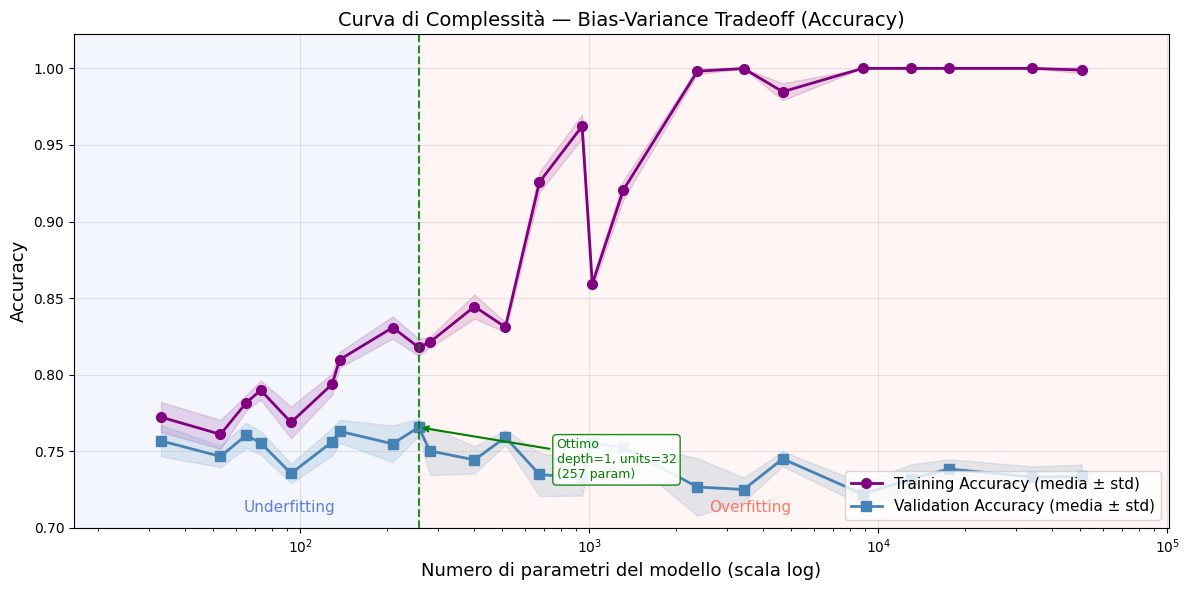

In [26]:
from utils import plot_complexity_curve

plot_complexity_curve(complexity_df)

### Interpretazione della curva di complessità

Il grafico mostra empiricamente le tre zone del bias-variance tradeoff:

- **Underfitting (sinistra)**: i modelli con pochi parametri presentano training accuracy e validation accuracy entrambe basse. Il modello non ha sufficiente capacità per catturare i pattern nei dati.
- **Zona ottimale (picco)**: in corrispondenza del massimo della curva di validazione, il modello raggiunge il miglior compromesso bias-varianza. L'errore di generalizzazione è minimizzato.
- **Overfitting (destra)**: i modelli con molti parametri raggiungono training accuracy elevata, ma la validation accuracy decresce. Il modello ha memorizzato il training set e non generalizza su dati nuovi.

#### Come la nested CV seleziona automaticamente la configurazione ottimale

Durante il **ciclo interno**, `GridSearchCV` valuta tutte le coppie `(depth, n_units)` usando $K' = 5$ fold: per ogni configurazione calcola la validation accuracy media sul ciclo interno. La coppia con la **validation accuracy media più alta** viene selezionata come ottimale per quel fold esterno.

Questo processo si ripete per ciascuno degli $K = 5$ fold esterni. 

In [27]:
# Stima di generalizzazione finale — ciclo esterno della nested CV
print("=" * 65)
print("STIMA DI GENERALIZZAZIONE — MLP ottimale (ciclo esterno)")
print("=" * 65)

for k, (score, params) in enumerate(
        zip(bv_results['outer_scores'], bv_results['best_params_per_fold']), 1):
    hls = params['clf__hidden_layer_sizes']
    depth_k   = len(hls)
    n_units_k = hls[0]
    n_par_k   = count_mlp_params(depth_k, n_units_k, n_features_mlp)
    print(f"Fold {k}: depth={depth_k}, units={n_units_k:3d} "
          f"({n_par_k:5d} param)  →  test accuracy = {score:.4f}")

print(f"\nMean accuracy (MLP)  : {bv_results['mean_score']:.4f} "
      f"+/- {bv_results['std_score']:.4f}")
print(f"Mean accuracy (Logit): {results['mean_score']:.4f} "
      f"+/- {results['std_score']:.4f}")

STIMA DI GENERALIZZAZIONE — MLP ottimale (ciclo esterno)
Fold 1: depth=1, units= 16 (  129 param)  →  test accuracy = 0.7712
Fold 2: depth=1, units= 32 (  257 param)  →  test accuracy = 0.8170
Fold 3: depth=1, units= 32 (  257 param)  →  test accuracy = 0.7516
Fold 4: depth=4, units=  8 (  281 param)  →  test accuracy = 0.7237
Fold 5: depth=3, units=  8 (  209 param)  →  test accuracy = 0.7303

Mean accuracy (MLP)  : 0.7588 +/- 0.0336
Mean accuracy (Logit): 0.7628 +/- 0.0305


### Conclusioni e confronto con la baseline logistica lineare

L'esperimento evidenzia i seguenti punti chiave:

1. **Il bias-variance tradeoff è empiricamente osservabile**: al crescere del numero di parametri dell'MLP, la validation accuracy descrive una curva a campana — prima cresce (riduzione del bias), poi decresce (aumento della varianza).

2. **La nested cross-validation seleziona automaticamente la complessità ottimale**: il ciclo interno agisce da filtro, scegliendo la coppia `(depth, n_units)` con la migliore validation accuracy. Il ciclo esterno stima l'accuracy di generalizzazione del modello ottimale in modo non distorto.

3. **Confronto con la baseline lineare**: la Logistic Regression è di per sé un modello a bassa complessità. Se l'MLP ottimale ottiene accuracy simile, ciò suggerisce che il problema è approssimativamente lineare nel feature space costruito — coerente con le conclusioni dell'EDA multivariata. Se l'MLP ottimale supera la baseline, esiste una non-linearità sfruttabile, secondo il bias induttivo introdotto dall'architettura MLP.